In [1]:
# Load dataset using pandas
import pandas as pd
df = pd.read_csv(r"C:\Users\Welcome Sir\Documents\Projects\Fraud Detection\creditcard.csv")

In [2]:
# display first rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Check shape and column types.
# Check for missing values.
print(df.info())
print ('Missing values info above')
print ('')
# Check for duplicate rows
print(df.duplicated().sum()) 
print ('Duplicate info above')
print ('')
# Display summary statistics.
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
# Remove the duplicate rows
# keep='first' is the default (it keeps the first occurrence and deletes the rest)
df = df.drop_duplicates(keep='first')

# Reset the index 
# Since rows were removed, the index will have gaps. This fixes it.
df = df.reset_index(drop=True)

# Verify that the count is now 0
print(f"Remaining duplicates: {df.duplicated().sum()}")

print('')
print('Done')

Remaining duplicates: 0

Done


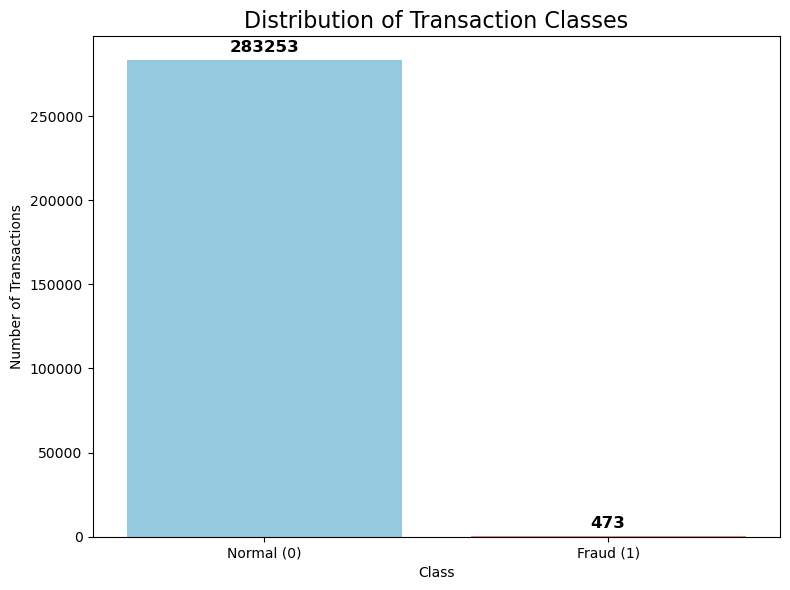

Total Transactions: 283726
Normal Transactions: 283253 (99.833%)
Fraudulent Transactions: 473 (0.167%)


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
# Class Distribution Plot
# Visualize the Imbalance
# Calculate counts and percentages
class_counts = df['Class'].value_counts()
fraud_percentage = (class_counts[1] / class_counts.sum()) * 100

# Initialize the plot
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Class', data=df, palette=['skyblue', 'salmon'], hue='Class', legend=False)

# Add title and labels
plt.title('Distribution of Transaction Classes', fontsize=16)
plt.xticks(ticks=[0, 1], labels=['Normal (0)', 'Fraud (1)'])
plt.ylabel('Number of Transactions')
plt.xlabel('Class')

# Add text labels on top of the bars to show exact counts
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print the imbalance ratio for your report
print(f"Total Transactions: {len(df)}")
print(f"Normal Transactions: {class_counts[0]} ({100 - fraud_percentage:.3f}%)")
print(f"Fraudulent Transactions: {class_counts[1]} ({fraud_percentage:.3f}%)")

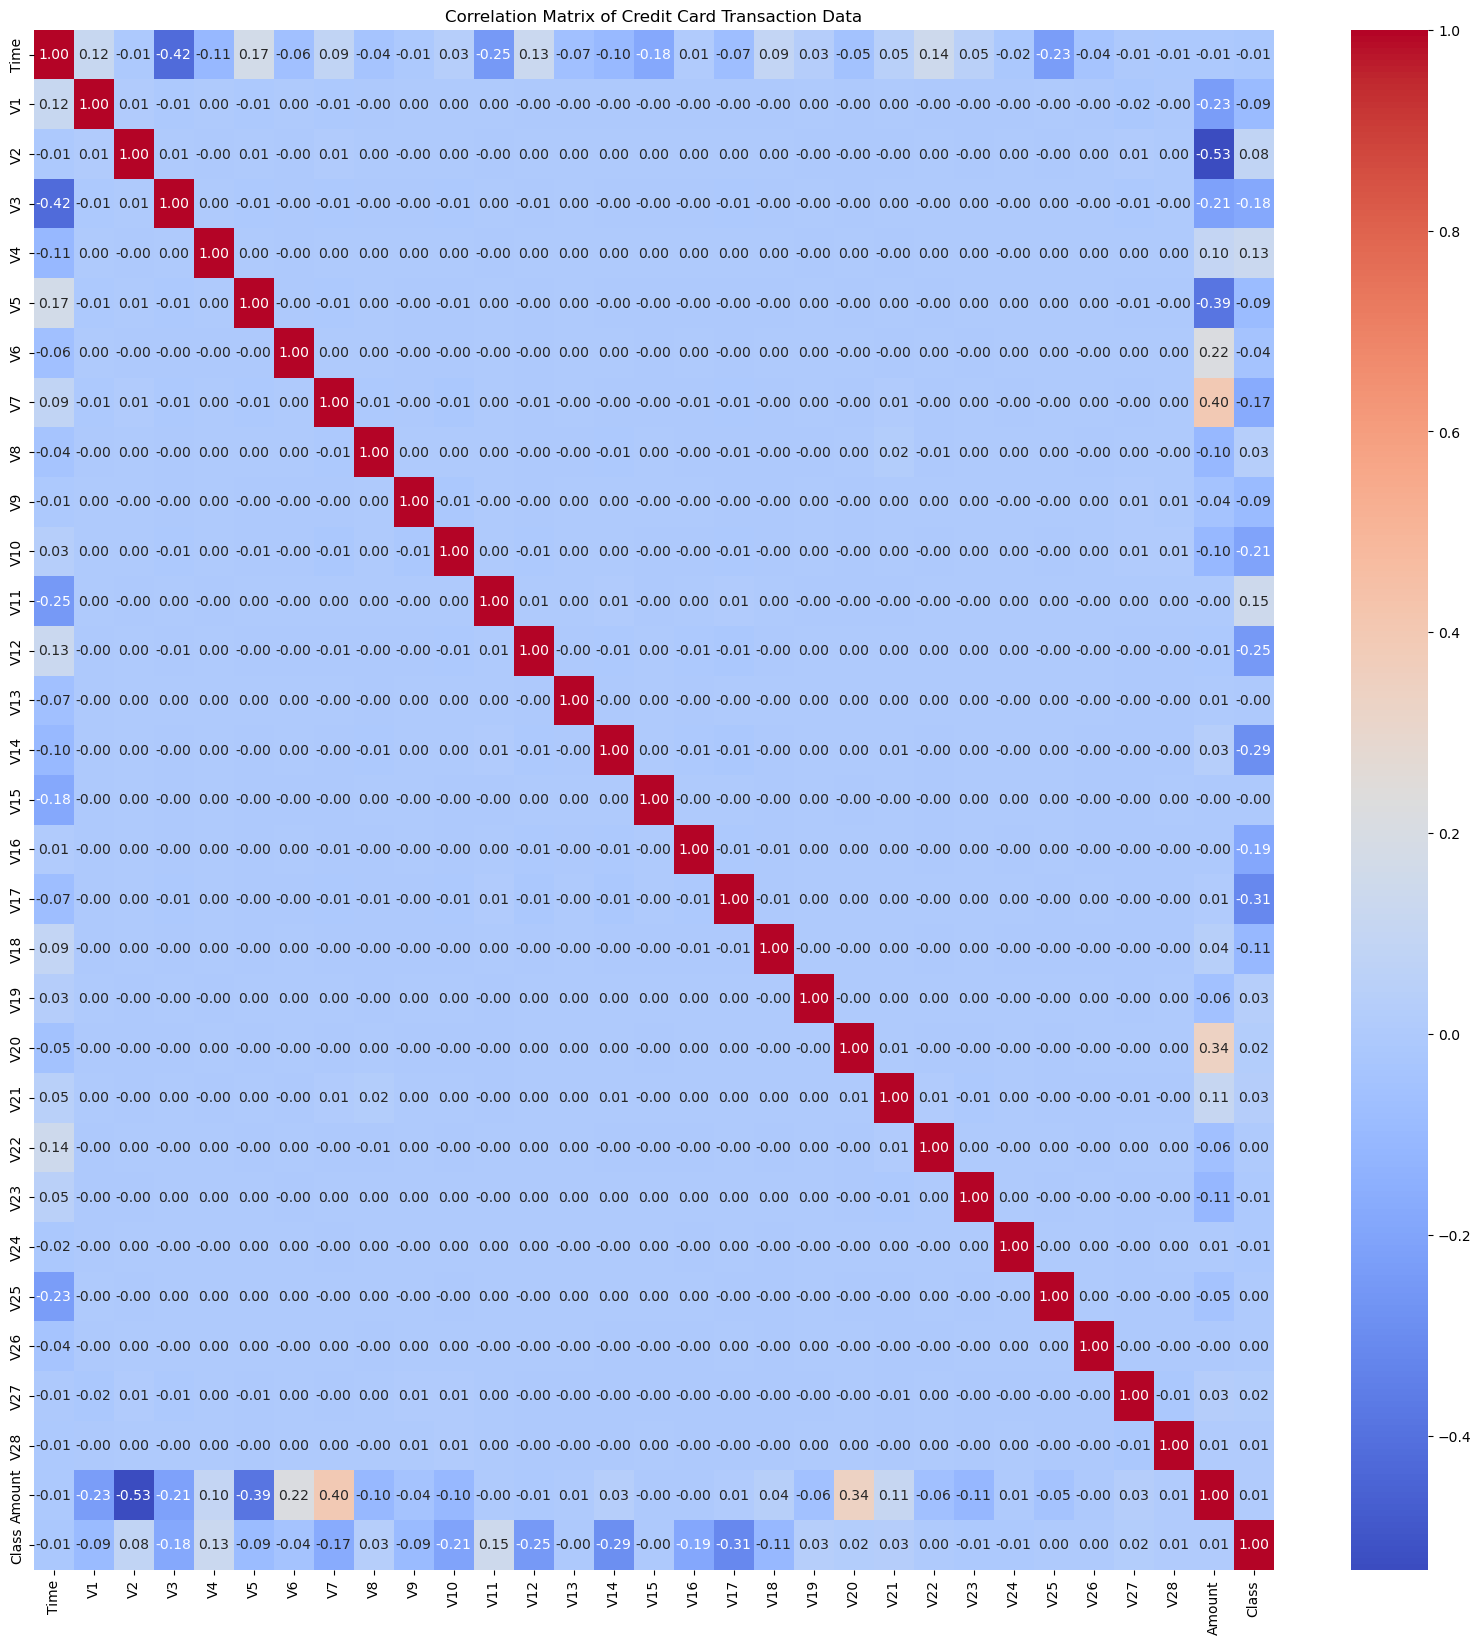

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
# 4. Select only the numerical columns for correlation
# (Correlation only works on numbers, not text like 'City' or 'Gender')
numerical_cols = ["Time","V1","V2","V3","V4","V5","V6","V7","V8","V9","V10","V11","V12","V13","V14","V15","V16","V17","V18","V19","V20","V21","V22","V23","V24","V25","V26","V27","V28","Amount","Class"]
corr_matrix = df[numerical_cols].corr()

# 5. Create the Heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Matrix of Credit Card Transaction Data')
plt.savefig(r"C:\Users\Welcome Sir\Documents\Projects\Fraud Detection\Seaborn Correlation Heatmap.png")
plt.show()

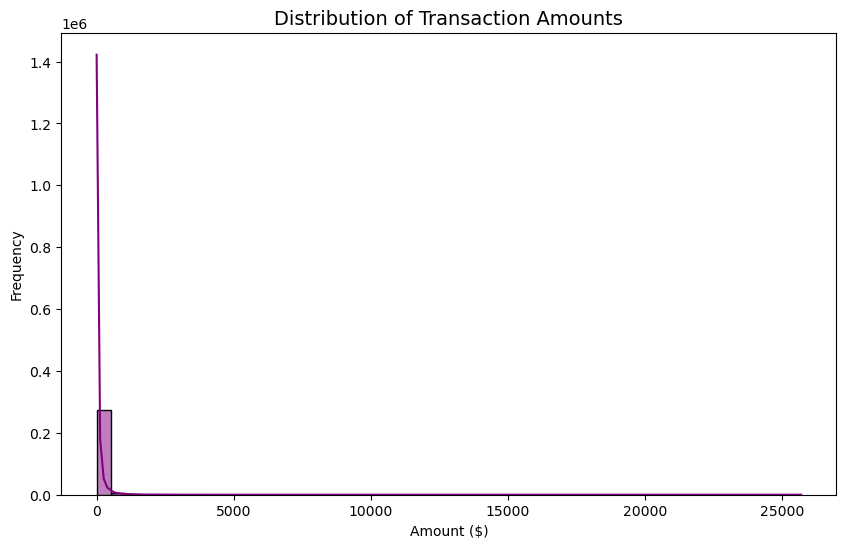

Skewness of Amount: 16.98


In [8]:
# Distribution of Amount
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=50, kde=True, color='purple')

plt.title('Distribution of Transaction Amounts', fontsize=14)
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')

# Adding a note about the skewness for the EDA report
plt.savefig(r"C:\Users\Welcome Sir\Documents\Projects\Fraud Detection\Distribution of Amount.png")
plt.show()
print(f"Skewness of Amount: {df['Amount'].skew():.2f}")

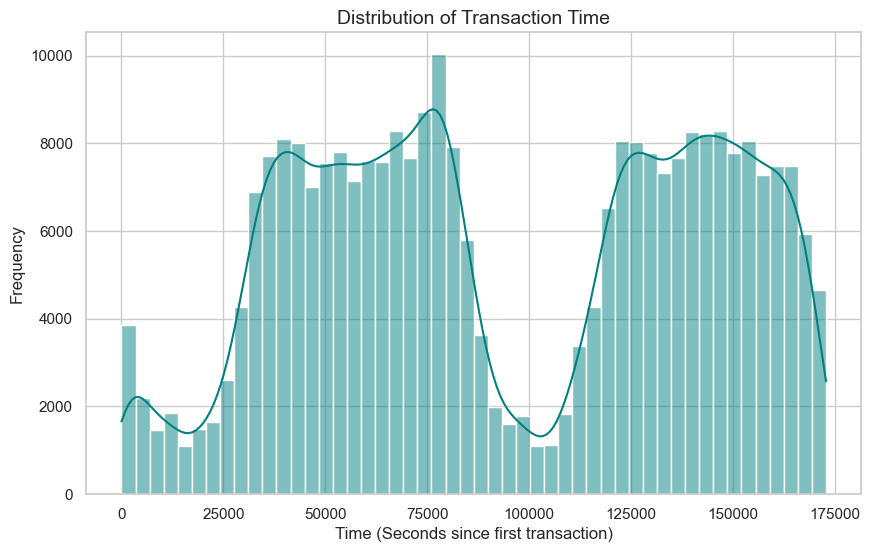

Skewness of Time: -0.04


In [18]:
# Distribution of Time
plt.figure(figsize=(10, 6))
sns.histplot(df['Time'], bins=50, kde=True, color='teal')

plt.title('Distribution of Transaction Time', fontsize=14)
plt.xlabel('Time (Seconds since first transaction)')
plt.ylabel('Frequency')

plt.savefig(r"C:\Users\Welcome Sir\Documents\Projects\Fraud Detection\Distribution of Time.png")
plt.show()
plt.show()
print(f"Skewness of Time: {df['Time'].skew():.2f}")

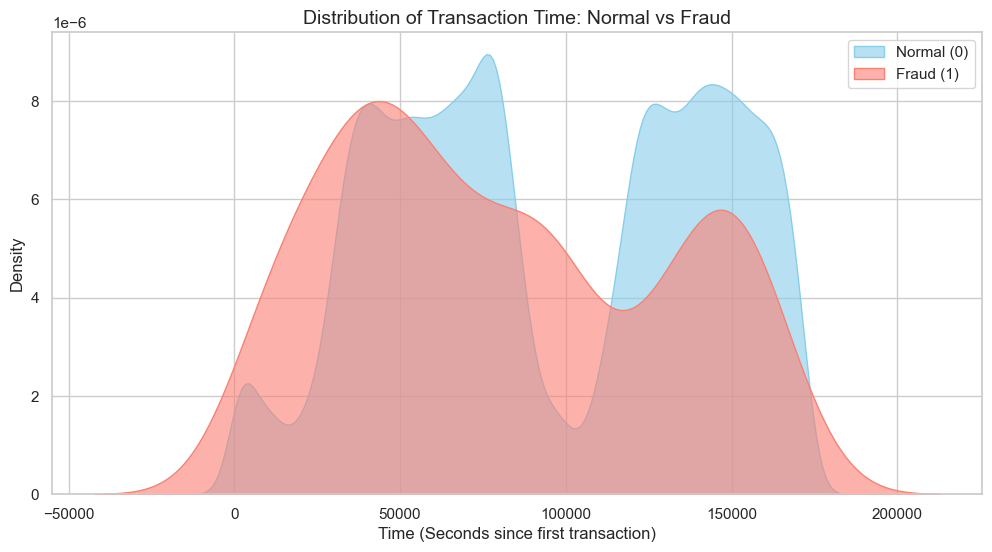

In [10]:
# 6. Plots to see if Frauds occur at certain times

# Set the visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

# KDE Plot for Time
sns.kdeplot(df[df['Class'] == 0]['Time'], label='Normal (0)', fill=True, color='skyblue', alpha=0.6)
sns.kdeplot(df[df['Class'] == 1]['Time'], label='Fraud (1)', fill=True, color='salmon', alpha=0.6)

plt.title('Distribution of Transaction Time: Normal vs Fraud', fontsize=14)
plt.xlabel('Time (Seconds since first transaction)')
plt.ylabel('Density')
plt.legend(loc='upper right')
plt.savefig(r"C:\Users\Welcome Sir\Documents\Projects\Fraud Detection\Density Plot for Transaction time Against Class.png")
plt.show()

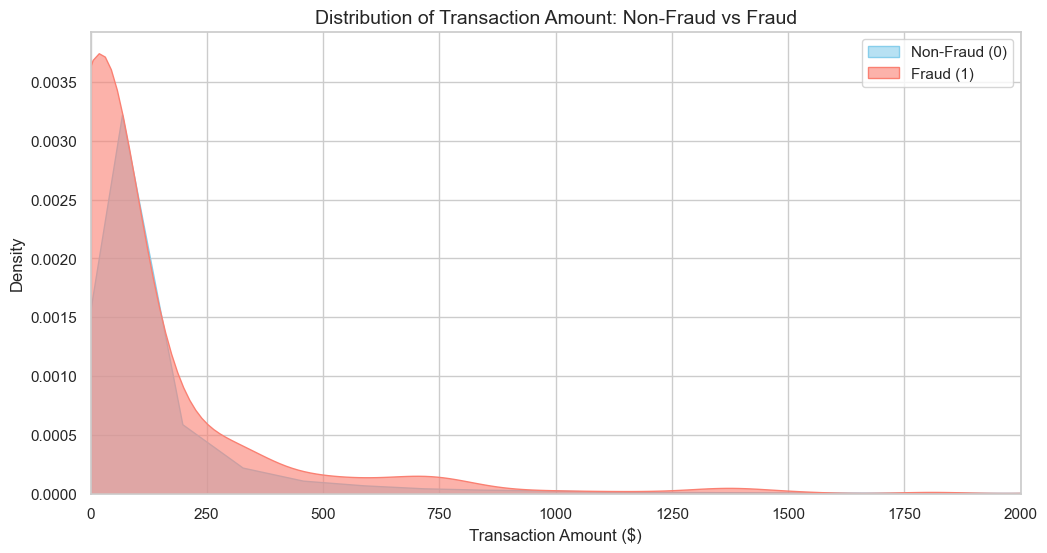

In [11]:
# 7. Density Plot for Transaction Amount
# We use a log scale or limit the x-axis because most transactions are small, 
# but a few are very large (outliers).
plt.figure(figsize=(12, 6))

# KDE Plot for Amount
sns.kdeplot(df[df['Class'] == 0]['Amount'], label='Non-Fraud (0)', fill=True, color='skyblue', alpha=0.6)
sns.kdeplot(df[df['Class'] == 1]['Amount'], label='Fraud (1)', fill=True, color='salmon', alpha=0.6)

# Limiting X-axis to see the distribution more clearly (ignoring extreme outliers)
plt.xlim([0, 2000]) 
plt.title('Distribution of Transaction Amount: Non-Fraud vs Fraud', fontsize=14)
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Density')
plt.legend(loc='upper right')
plt.savefig(r"C:\Users\Welcome Sir\Documents\Projects\Fraud Detection\Density Plot for Transaction Amount Against Class.png")
plt.show()

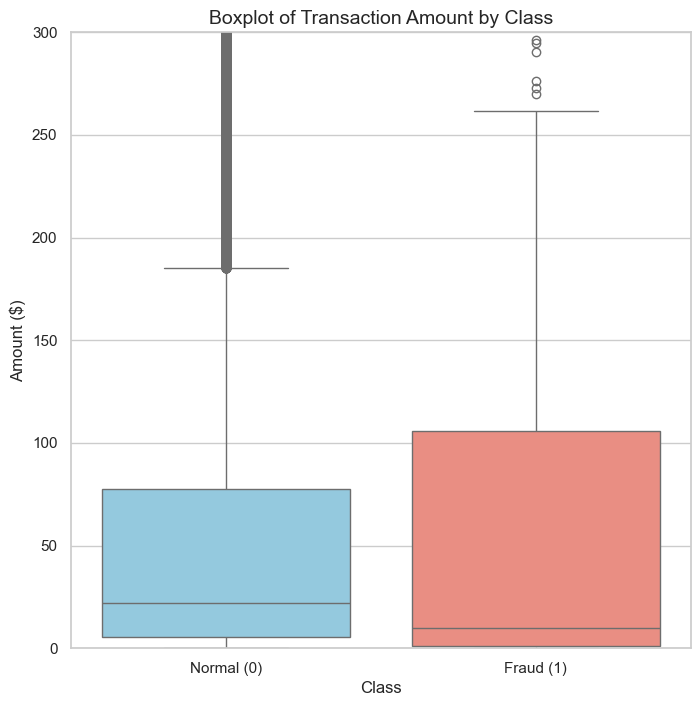

Descriptive Statistics for Transaction Amount:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


In [12]:
# Boxplots for Amount by Class
plt.figure(figsize=(8, 8))

# Creating the boxplot
sns.boxplot(x='Class', y='Amount', data=df, palette=['skyblue', 'salmon'], hue='Class', legend=False)

# Setting labels and title
plt.title('Boxplot of Transaction Amount by Class', fontsize=14)
plt.xticks(ticks=[0, 1], labels=['Normal (0)', 'Fraud (1)'])
plt.xlabel('Class')
plt.ylabel('Amount ($)')

# IMPORTANT: We limit the Y-axis to see the boxes clearly. 
# Without this, the few $20,000+ outliers make the boxes look like flat lines.
plt.ylim(0, 300) 

plt.savefig(r"C:\Users\Welcome Sir\Documents\Projects\Fraud Detection\Boxplot of Transaction Amount by Class.png")
plt.show()

# Display descriptive statistics for Amount per class to supplement the plot
print("Descriptive Statistics for Transaction Amount:")
print(df.groupby('Class')['Amount'].describe())

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Define Features and Target
# Based on our discussion, we'll keep all features for now
X = df.drop(['Class'], axis=1)
y = df['Class']

# 2. Stratified Split (80/20) - Requirement Phase 1, Step 5
# Stratify=y ensures both sets have the same % of fraud
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Feature Scaling - Requirement Phase 1, Step 4
scaler = StandardScaler()

# We fit only on Train and transform both
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

# SAVE THE SCALER NOW for the FastAPI backend later
joblib.dump(scaler, r"C:\Users\Welcome Sir\Documents\Projects\Fraud Detection\scaler.pkl")
print('Scaling Complete')

Scaling Complete


In [14]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# SMOTE Version
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

# Undersampled Version
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
print('Imbalance Handled!')

Imbalance Handled!


Training Logistic Regression on Original data...
Training Random Forest on Original data...
Training Gradient Boosting on Original data...
Training Logistic Regression on Undersampled data...
Training Random Forest on Undersampled data...
Training Gradient Boosting on Undersampled data...
Training Logistic Regression on SMOTE data...
Training Random Forest on SMOTE data...
Training Gradient Boosting on SMOTE data...

--- Final Model Comparison Table ---
                 Model       Dataset  TP    FP     TN  FN  Precision  Recall  \
7        Random Forest         SMOTE  72     7  56644  23     0.9114  0.7579   
1        Random Forest      Original  69     2  56649  26     0.9718  0.7263   
8    Gradient Boosting         SMOTE  80   616  56035  15     0.1149  0.8421   
4        Random Forest  Undersampled  83   896  55755  12     0.0848  0.8737   
6  Logistic Regression         SMOTE  83  1482  55169  12     0.0530  0.8737   
0  Logistic Regression      Original  83  1393  55258  12     

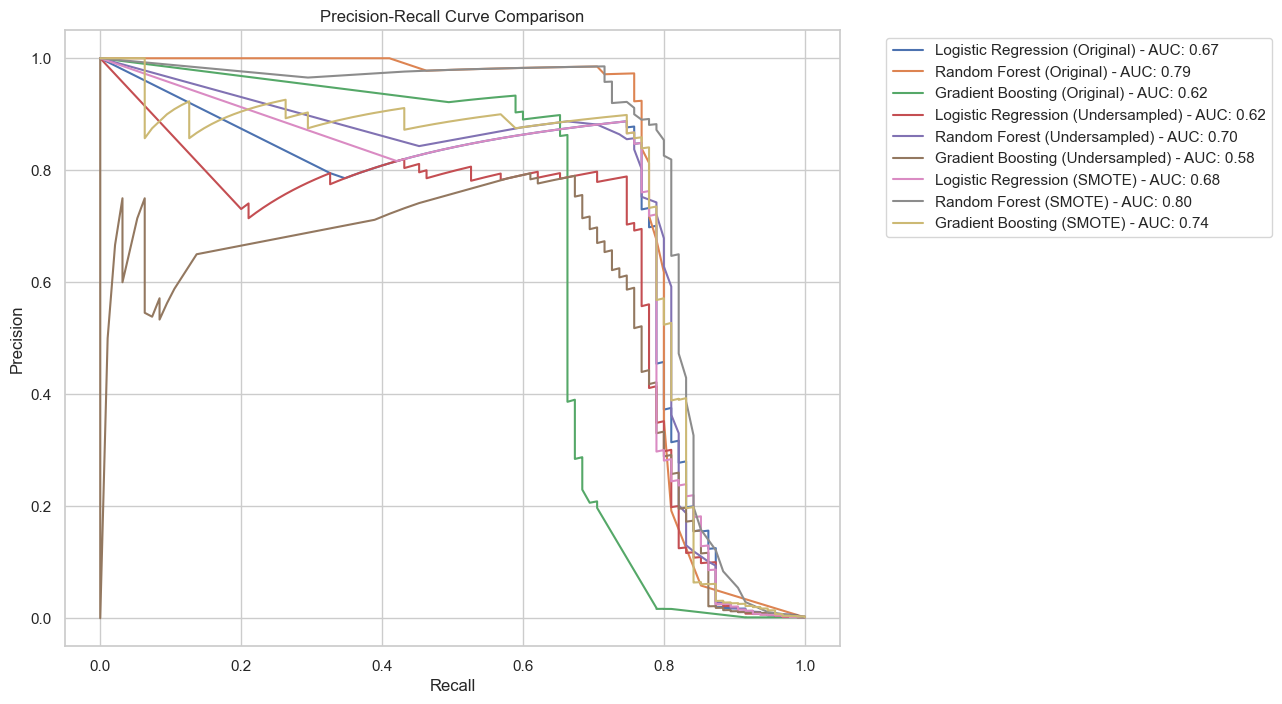

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, precision_score, recall_score, 
    f1_score, roc_auc_score, average_precision_score, precision_recall_curve
)

# 1. Define the Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 2. Define the Datasets
datasets = {
    "Original": (X_train, y_train),
    "Undersampled": (X_train_under, y_train_under),
    "SMOTE": (X_train_smote, y_train_smote)
}

# Store all results for final comparison
performance_metrics = []

plt.figure(figsize=(10, 8))

# 3. The Experiment Loop
for data_name, (X_d, y_d) in datasets.items():
    for model_name, model in models.items():
        print(f"Training {model_name} on {data_name} data...")
        
        # Fit
        model.fit(X_d, y_d)
        
        # Predict
        y_pred = model.predict(X_test)
        y_probs = model.predict_proba(X_test)[:, 1]
        
        # Calculate Metrics
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_probs)
        pr_auc = average_precision_score(y_test, y_probs)
        
        # Store results
        performance_metrics.append({
            "Model": model_name,
            "Dataset": data_name,
            "TP": tp, "FP": fp, "TN": tn, "FN": fn,
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1": round(f1, 4),
            "ROC-AUC": round(roc_auc, 4),
            "PR-AUC": round(pr_auc, 4)
        })
        
        # Plot PR Curve for the current model
        prec, rec, _ = precision_recall_curve(y_test, y_probs)
        plt.plot(rec, prec, label=f"{model_name} ({data_name}) - AUC: {pr_auc:.2f}")

# 4. Final Comparison Table
df_results = pd.DataFrame(performance_metrics)
print("\n--- Final Model Comparison Table ---")
print(df_results.sort_values(by="PR-AUC", ascending=False))

# 5. Finalize PR Curve Plot
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.savefig(r"C:\Users\Welcome Sir\Documents\Projects\Precision-Recall Curve Comparison.png")
plt.show()

In [16]:
import joblib

best_model = models["Random Forest"].fit(X_train_smote, y_train_smote)

joblib.dump(best_model, r'C:\Users\Welcome Sir\Documents\Projects\Fraud Detection\fraud_model.pkl')
print("Best model saved as fraud_model.pkl")

Best model saved as fraud_model.pkl


In [ ]:
# Inference Function
from fastapi import FastAPI
from pydantic import BaseModel

# 1. Load the artifacts you saved during Phase 2
model = joblib.load("fraud_model.pkl")
scaler = joblib.load("scaler.pkl")

app = FastAPI()

# 2. Define the input schema (Requirement Phase 3)
class Transaction(BaseModel):
    Time: float
    V1: float
    V2: float
    V3: float
    V4: float
    V5: float
    V6: float
    V7: float
    V8: float
    V9: float
    V10: float
    V11: float
    V12: float
    V13: float
    V14: float
    V15: float
    V16: float
    V17: float
    V18: float
    V19: float
    V20: float
    V21: float
    V22: float
    V23: float
    V24: float
    V25: float
    V26: float
    V27: float
    V28: float
    Amount: float

@app.post("/predict")
def predict_fraud(data: Transaction):
    # 3. Convert input to a DataFrame (easier for scaling)
    input_data = pd.DataFrame([data.dict()])
    
    # 4. Apply the Scaler to Time and Amount ONLY
    # This must match exactly what you did in the notebook
    input_data[['Time', 'Amount']] = scaler.transform(input_data[['Time', 'Amount']])
    
    # 5. Make the prediction
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]
    
    # 6. Return the response (Requirement Phase 3)
    status = "Fraudulent transaction detected" if prediction == 1 else "Legitimate transaction"
    
    return {
        "prediction": int(prediction),
        "probability": round(float(probability), 4),
        "message": status
    }